## NAV Trend Analysis

1) The average NAV across all schemes showed a steady upward trend between 2022 and 2026.

2) Periods of stronger growth indicate bullish market conditions, while temporary declines reflect market corrections.

3) Overall, mutual fund NAVs demonstrated long-term appreciation.

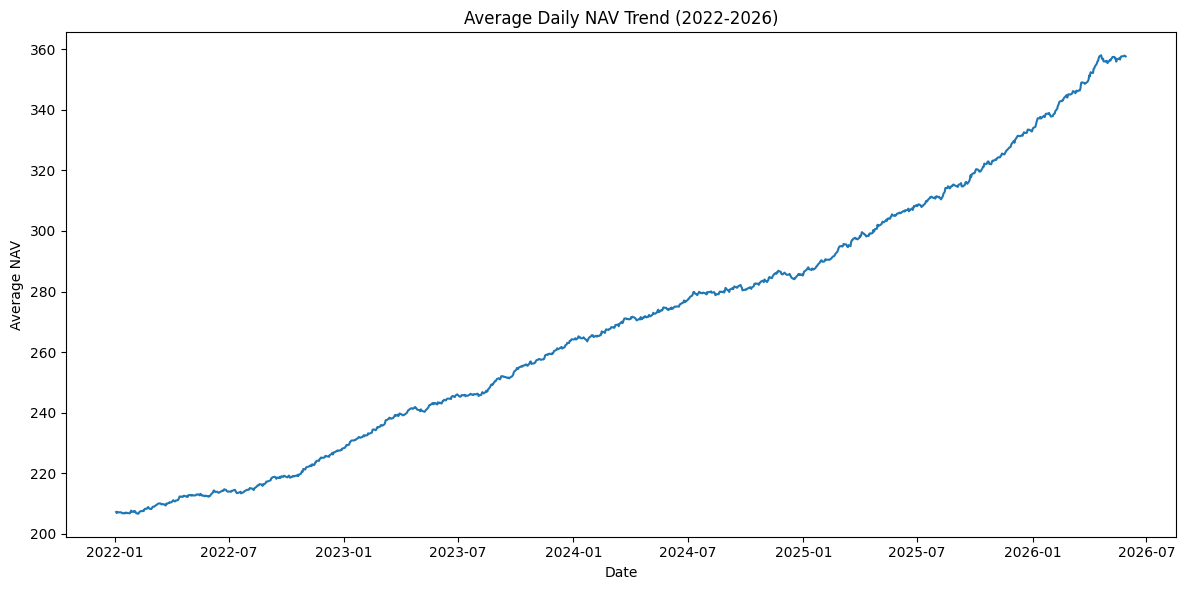

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/clean_nav_history.csv")
nav["date"] = pd.to_datetime(nav["date"])
daily_nav = nav.groupby("date")["nav"].mean()

plt.figure(figsize=(12,6))
plt.plot(daily_nav.index, daily_nav.values)

plt.title("Average Daily NAV Trend (2022-2026)")
plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.tight_layout()
plt.savefig("../charts/nav_trend.png")
plt.show()

## AUM Growth by Fund House

1) This chart compares Assets Under Management (AUM) across fund houses over time.

2) Higher AUM indicates stronger investor confidence and larger market share.

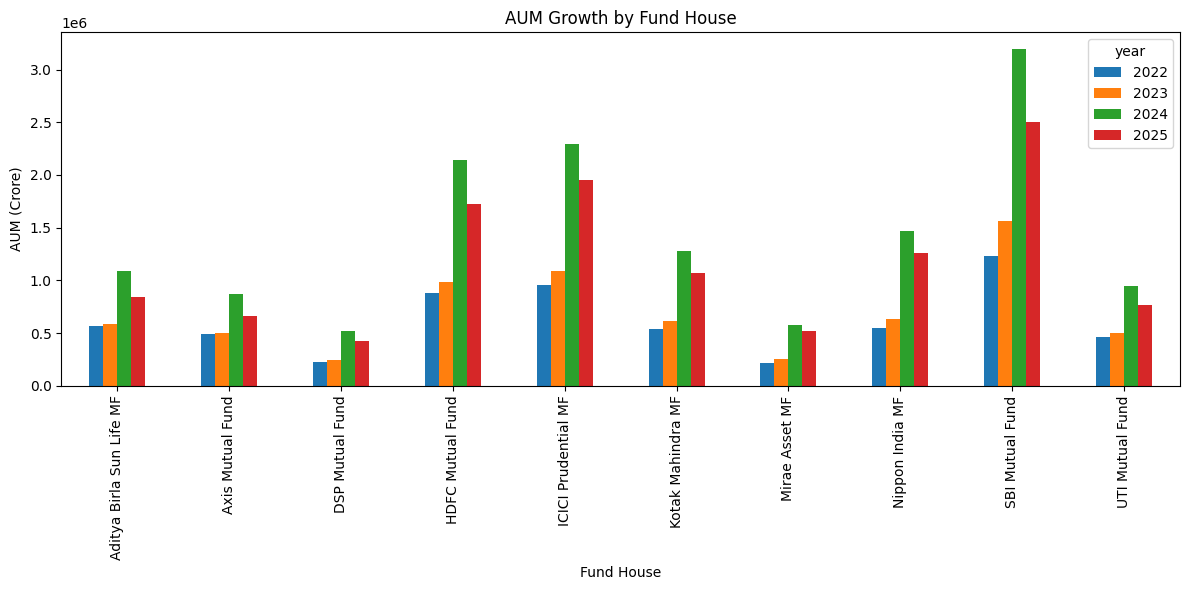

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

grouped = (
    aum.groupby(["year", "fund_house"])["aum_crore"]
    .sum()
    .reset_index()
)

pivot = grouped.pivot(
    index="fund_house",
    columns="year",
    values="aum_crore"
)

pivot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("AUM Growth by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")
plt.tight_layout()

plt.savefig("../charts/aum_growth.png")

plt.show()

## SIP Inflow Trend

1) This chart shows monthly SIP inflows from 2022 to 2025.

2) A significant milestone was reached in December 2025 when SIP inflows crossed ₹31,000 crore, reflecting strong retail investor participation.

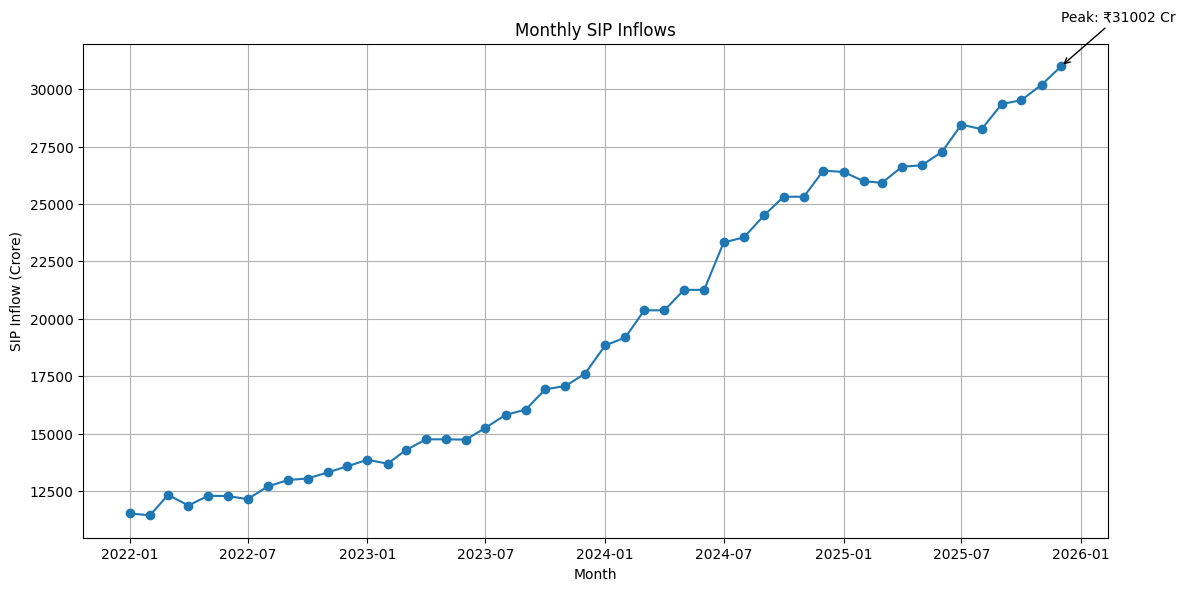

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
sip["month"] = pd.to_datetime(sip["month"])
plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

plt.annotate(
    f"Peak: ₹{max_row['sip_inflow_crore']:.0f} Cr",
    xy=(max_row["month"], max_row["sip_inflow_crore"]),
    xytext=(max_row["month"], max_row["sip_inflow_crore"] + 2000),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.tight_layout()
plt.savefig("../charts/sip_inflow_trend.png")
plt.show()

In [7]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

print(max_row)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object
